In [1]:
pip install torch torchvision opencv-python matplotlib grad-cam

In [2]:
from io import BytesIO
from PIL import Image
from tqdm.auto import tqdm
from pytorch_grad_cam import GradCAM
from matplotlib import pyplot as plt
from sklearn.metrics import f1_score
from torch.utils.data import DataLoader,Dataset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from pytorch_grad_cam.utils.image import show_cam_on_image
from sklearn.metrics import classification_report, f1_score
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [3]:
import os
import cv2
import torch
import random
import requests
import kagglehub
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import torchvision.models as models

In [4]:
BATCH_SIZE = 16
EPOCHS = 5
LEARNING_RATE = 0.001
LR = 3e-4
WD = 1e-4
CLASSES = ["fake", "real"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
path = kagglehub.dataset_download("preetrank/indian-currency-real-vs-fake-notes-dataset")

Using Colab cache for faster access to the 'indian-currency-real-vs-fake-notes-dataset' dataset.


In [6]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

In [7]:
path = kagglehub.dataset_download("preetrank/indian-currency-real-vs-fake-notes-dataset")
print("Downloaded to cache folder:", path)

# List out the contents to find the image directories
for root, dirs, files in os.walk(path):
    # Only print directories that contain files to keep it clean
    if files:
        print(f"Directory: {root} contains {len(files)} files")

Using Colab cache for faster access to the 'indian-currency-real-vs-fake-notes-dataset' dataset.
Downloaded to cache folder: /kaggle/input/indian-currency-real-vs-fake-notes-dataset
Directory: /kaggle/input/indian-currency-real-vs-fake-notes-dataset/Features/Features/20_Features contains 258 files
Directory: /kaggle/input/indian-currency-real-vs-fake-notes-dataset/Features/Features/50_Features contains 187 files
Directory: /kaggle/input/indian-currency-real-vs-fake-notes-dataset/Features/Features/10_Features contains 240 files
Directory: /kaggle/input/indian-currency-real-vs-fake-notes-dataset/Features/Features/200_Features contains 125 files
Directory: /kaggle/input/indian-currency-real-vs-fake-notes-dataset/Features/Features/2000_Features contains 147 files
Directory: /kaggle/input/indian-currency-real-vs-fake-notes-dataset/Features/Features/100_Features contains 229 files
Directory: /kaggle/input/indian-currency-real-vs-fake-notes-dataset/Features/Features/500_Features contains 132 

In [8]:
classes = ["fake", "real"]
class_to_idx = {c: i for i, c in enumerate(classes)}
all_images, all_labels = [], []

In [9]:
for cls in classes:
    base_folder = os.path.join(path, "data", "data", cls)
    for denom in os.listdir(base_folder):  # 10, 20, 50, etc.
        denom_path = os.path.join(base_folder, denom)
        if not os.path.isdir(denom_path):
            continue
        for fname in os.listdir(denom_path):
            if fname.lower().endswith(tuple([".jpg", ".jpeg", ".png"])):
                all_images.append(os.path.join(denom_path, fname))
                all_labels.append(class_to_idx[cls])

In [10]:
print(f"Total images found: {len(all_images)}")
print(f"Class distribution: Real={sum(np.array(all_labels)==1)}, Fake={sum(np.array(all_labels)==0)}")

Total images found: 7442
Class distribution: Real=4937, Fake=2505


In [11]:
X_train, X_val, y_train, y_val = train_test_split(all_images, all_labels, test_size=0.25, random_state=SEED, stratify=all_labels)
print(f"Number of training images: {len(X_train)}")
print(f"Number of validation images: {len(X_val)}")

Number of training images: 5581
Number of validation images: 1861


In [12]:
train_transform = transforms.Compose([transforms.Resize((224, 224)),transforms.RandomHorizontalFlip(),transforms.ToTensor(),transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])


In [13]:
val_transform = transforms.Compose([transforms.Resize((224, 224)),transforms.ToTensor(),transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

In [14]:
class ImageDataset(Dataset):
    def __init__(self, paths, labels, tfm):
        self.paths = paths
        self.labels = labels
        self.tfm = tfm

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        img = self.tfm(img)
        label = self.labels[idx]
        return img, label

train_loader = DataLoader(
    ImageDataset(X_train, y_train, train_transform),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
val_loader = DataLoader(
    ImageDataset(X_val, y_val, val_transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True)

In [15]:
weights = models.ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights)
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, 2)
)

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)

model = model.to(DEVICE)

In [16]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.amp.GradScaler(device='cuda', enabled=(DEVICE == "cuda"))

In [17]:
def evaluate(return_preds=False):
    model.eval()
    preds, gts = [], []
    with torch.no_grad():
        for x, y in tqdm(val_loader, desc="Validating", leave=False):
            x, y = x.to(DEVICE), y.to(DEVICE)
            with torch.amp.autocast('cuda', enabled=(DEVICE == "cuda")):
                logits = model(x)
            preds.extend(logits.argmax(1).cpu().numpy().tolist())
            gts.extend(y.cpu().numpy().tolist())

    preds_np = np.array(preds)
    gts_np = np.array(gts)

    acc = np.mean(preds_np == gts_np)
    f1 = f1_score(gts_np, preds_np)

    if return_preds:
        return preds, gts
    return acc, f1

In [18]:
best_f1 = 0.0
for epoch in range(1, EPOCHS + 1):
    model.train()
    loop = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False)
    for x, y in loop:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=(DEVICE == "cuda")):
            logits = model(x)
            loss = criterion(logits, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        loop.set_postfix(loss=float(loss.item()))

    scheduler.step()
    acc, f1 = evaluate()
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), "resnet50_currency_best.pt")
    print(f"Epoch {epoch:02d}/{EPOCHS} - val_acc={acc:.4f} val_f1={f1:.4f}")

Epoch 1/5:   0%|          | 0/349 [00:00<?, ?it/s]

Validating:   0%|          | 0/117 [00:00<?, ?it/s]

Epoch 01/5 - val_acc=0.9758 val_f1=0.9820


Epoch 2/5:   0%|          | 0/349 [00:00<?, ?it/s]

Validating:   0%|          | 0/117 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/117 [00:00<?, ?it/s]

Epoch 04/5 - val_acc=0.9930 val_f1=0.9947


Epoch 5/5:   0%|          | 0/349 [00:00<?, ?it/s]

Validating:   0%|          | 0/117 [00:00<?, ?it/s]

Epoch 05/5 - val_acc=0.9919 val_f1=0.9939


In [19]:


print("\nLoading best model and generating final classification report...")
model.load_state_dict(torch.load("resnet50_currency_best.pt", map_location=DEVICE))

# The evaluate function with return_preds=True only returns preds and gts.
preds, gts = evaluate(return_preds=True)

# Calculate acc and f1 from the returned predictions and ground truths
preds_np = np.array(preds)
gts_np = np.array(gts)
acc = np.mean(preds_np == gts_np)
f1 = f1_score(gts_np, preds_np)

print("\n===================== FINAL RESULTS =====================")
print(f"Test Accuracy: {acc:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(gts, preds, target_names=classes))
print("==========================================================")


Loading best model and generating final classification report...


Validating:   0%|          | 0/117 [00:00<?, ?it/s]


===================== FINAL RESULTS =====================
Test Accuracy: 0.9930
Test F1 Score: 0.9947

Classification Report:
              precision    recall  f1-score   support

        fake       0.99      0.99      0.99       626
        real       0.99      1.00      0.99      1235

    accuracy                           0.99      1861
   macro avg       0.99      0.99      0.99      1861
weighted avg       0.99      0.99      0.99      1861



In [20]:
model_filename = "resnet50_currency_best.pt"
model_path = os.path.abspath(model_filename)
print(f"Model saved at: {model_path}")

Model saved at: /content/resnet50_currency_best.pt


In [21]:
weights = models.ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights)
in_features = model.fc.in_features
model.fc = torch.nn.Sequential(torch.nn.Dropout(0.3),torch.nn.Linear(in_features, 2))

In [22]:
state_dict = torch.load(model_path, map_location=DEVICE)

if any(k.startswith("module.") for k in state_dict.keys()):
    state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
model.load_state_dict(state_dict)
model.to(DEVICE)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [23]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

In [24]:
# Define IMG_PATH with a sample image path from X_val
IMG_PATH = X_val[0] # Assuming X_val is available in the kernel state

if IMG_PATH.startswith("http"):
    response = requests.get(IMG_PATH)
    response.raise_for_status()
    img_pil = Image.open(BytesIO(response.content)).convert("RGB")
else:
    img_pil = Image.open(IMG_PATH).convert("RGB")

img_tensor = transform(img_pil).unsqueeze(0).to(DEVICE)

In [25]:
target_layer = model.layer4[-1].conv3  # last conv layer in ResNet50

gradients = []
activations = []

def save_gradient(grad):
    gradients.append(grad)

def forward_hook(module, inp, out):
    activations.append(out)

# Register hooks
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(lambda m, grad_in, grad_out: save_gradient(grad_out[0]))

output = model(img_tensor)
pred_class = output.argmax(dim=1).item()
confidence = torch.softmax(output, dim=1)[0][pred_class].item()

# Compute Gradients
model.zero_grad()
class_score = output[0, pred_class]
class_score.backward()

# Extract gradients & activations
grads = gradients[0].cpu().detach().numpy()[0]
acts = activations[0].cpu().detach().numpy()[0]

# Global average pooling of gradients
weights = np.mean(grads, axis=(1, 2))
cam = np.zeros(acts.shape[1:], dtype=np.float32)

for i, w in enumerate(weights):
    cam += w * acts[i, :, :]

# Normalize CAM
cam = np.maximum(cam, 0)
cam = cam / cam.max()

# Resize CAM to image size
cam = cv2.resize(cam, (224, 224))
heatmap = np.uint8(255 * cam)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

In [26]:
img_cv = np.array(img_pil)
img_cv = cv2.cvtColor(img_cv, cv2.COLOR_RGB2BGR)
heatmap = cv2.resize(heatmap, (img_cv.shape[1], img_cv.shape[0]))
overlay = cv2.addWeighted(img_cv, 0.6, heatmap, 0.4, 0)

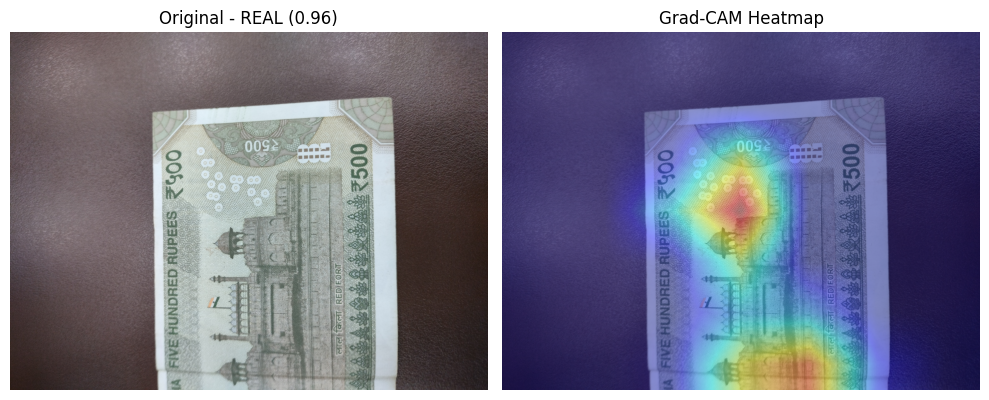

Prediction: REAL (Confidence: 0.957)


In [27]:

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
plt.title(f"Original - {CLASSES[pred_class].upper()} ({confidence:.2f})")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM Heatmap")
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"Prediction: {CLASSES[pred_class].upper()} (Confidence: {confidence:.3f})")
